<a href="https://colab.research.google.com/github/Aribu4/CQ-/blob/main/CQ_DEEC_jlobo_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Começar a usar o qiskit para implementar um circuito quântico

...


Como estamos no colab, vamos instalar o Qiskit nesta sessão

In [ ]:
%pip install qiskit pylatexenc  # O pylatexenc é só para criar imagens de circuitos mais bonitas

E importar algumas bibliotecas que vão ser úteis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Criar o circuito

 ```QuantumCircuit``` é a classe para criar circuitos que temos que importar.



In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

Primeiro, vamos criar um registo com um qubit que fica numa lista ```qreg``` que vai ter apenas um elemento.

In [ ]:
qreg = QuantumRegister(1, 'q')  # qubit

Vamos então criar o nosso primeiro circuito, com os qubits/bits que criámos.

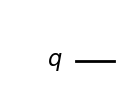

In [ ]:
qc = QuantumCircuit(qreg, name='MyCircuit')
qc.draw('mpl')

Aplicamos agora o primeiro gate. Vai ser o gate de Hadamard, $H$, ao primeiro (e único!) qubit.

Nota: o qubit é o primeiro elemento da lista ```qreg```. O primeiro elemento de uma lista tem sempre o índice zero.

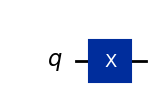

In [ ]:
qubit = qreg[0]
qc.x(qubit)  # Gate X
qc.draw('mpl')

Agora aplicar a gate $H$.

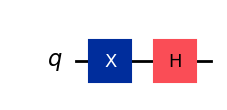

In [ ]:
qc.h(qreg[0])
qc.draw('mpl')

Para fazer uma medição temos que ter um bit classico para guardar o resultado.

Novamente, o bit clássico é o primeiro elemento da lista ```creg```.

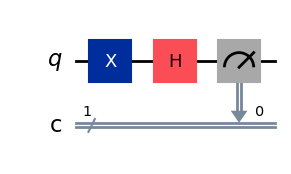

In [ ]:
creg = ClassicalRegister(1, 'c')  # Bit clássico -- para guardar resultados da medição
qc = QuantumCircuit(qreg, creg, name='Primeiro circuito') # reconstruir o circuito
qc.x(qubit)
qc.h(qubit)

bit = creg[0]
qc.measure(qubit, bit)
qc.draw('mpl')

## Simular o circuito

### Usando o ```StatevectorSampler```

O qiskit permite simular circuitos usando os chamados "samplers".

Eles simulam a evolução quântica e no fim dão um resultado (probabilístico) da medição.

Começamos por importar o sampler e uma função para visualizar os resultados.

In [ ]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
sampler = StatevectorSampler()

Como a computação quântica é probabilística, temos de correr os circuitos várias vezes para conseguir infereir o resultado.

Vamos escolher simular um circuito apenas 128 vezes, mas geralente será mais, quanto vezes será bom..., não sabemos...

In [ ]:
NSHOTS = 128

Vamos então chamar o sampler para correr o circuito. O sampler está à espera de uma lista de circuitos. Neste caso temos apenas um, por isso passamos uma lista com um só elemento.

In [ ]:
job = sampler.run([qc], shots=NSHOTS)
print(job.status())

JobStatus.DONE


O sampler devolve-nos um "job". Um job vai conter informação sobre os circuitos a correr, assim como os resultados das medições.

Vamos ver se o job já terminou.

In [ ]:
job.status()

<JobStatus.DONE: 'job has successfully run'>

Tendo terminado, vamos agora extrair os resultados.

Nós queremos o resultado do primeiro (e único) circuito que corremos.

In [ ]:
result = job.result()[0]

Finalmente, vamos ver as contagens das medições. Quantas vezes é que medimos |0> e quantas vezes medimos |1>?

In [ ]:
counts = result.data.c.get_counts()
counts

{'1': 60, '0': 68}

Podemos visualizar estes resultados usando um histograma. O Qiskit tem já uma função para isso.

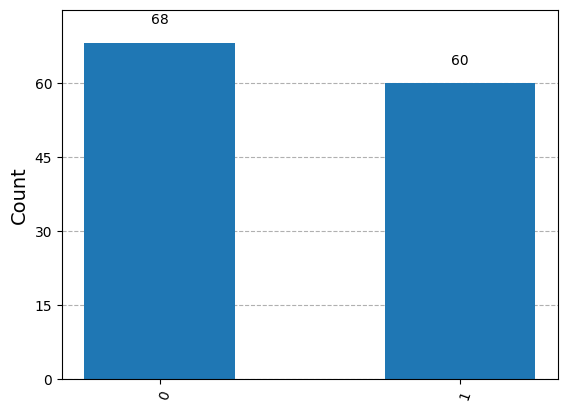

In [ ]:
plot_histogram(counts)